In [ ]:
# LangGraph :

In [ ]:
from IPython.display import Image
Image("/content/graph.jpg", width=500)

In [ ]:
## Graph :
    -- Nodes :
    -- Edges :

In [1]:
!pip install langgraph

In [ ]:
# Input   --> Input_First  --> Input_First_Second

In [2]:
def first_function(input):
  return input + "_First"

In [3]:
def second_function(input):
  return input + "_second"

In [ ]:
## Steps to build Graph :
1. Define Graph
2. Add Nodes & Edges
3. Set Entry point & Finish point
4. Compile graph

In [ ]:
from langgraph.graph import StateGraph

graph = StateGraph(str)

graph.add_node("My-Node", first_function)
graph.add_node("Node-2", second_function)

graph.add_edge("My-Node", "Node-2")

graph.set_entry_point("My-Node")
graph.set_finish_point("Node-2")

app = graph.compile()

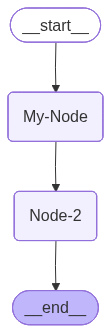

In [ ]:
app

In [ ]:
app.invoke("random")

'random_First_second'

In [ ]:
for out in app.stream("random"):
  print(out)

{'Node-1': 'random_First'}
{'Node-2': 'random_First_second'}


In [ ]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(str)

graph.add_node("My-Node", first_function)
graph.add_node("Node-2", second_function)

graph.add_edge("My-Node", "Node-2")

graph.add_edge(START, "My-Node")
# graph.set_entry_point("My-Node")

graph.add_edge("Node-2", END)
# graph.set_finish_point("Node-2")

app = graph.compile()

app.invoke("random")

'random_First_second'

In [ ]:
## Concepts in LangGraph :

Node : Python Function
       graph.add_node("Name-of-Node", function_to_run)

## Special Nodes :
START : Set Entry point
END : Set Finish Point

## Entry Point : Starting of Graph
graph.set_entry_point("My-Node") ~= graph.add_edge(START, "My-Node")

## Finish Point : Ending of Graph
graph.set_finish_point("Node-2")  ~= graph.add_edge("Node-2", END)



In [ ]:
Edges : Connection between two nodes

## Types of Edges :
1. Normal Edge : graph.add_edge("from node", "to node")
2. Conditional Edge : graph.add_conditional_edge("from node", "to node", condition)

###State :

In [ ]:
# State : It is a shared that is accessible to all nodes

## While defining graph : mention data type of state
graph = StateGraph(list)  --> str, int, float, bool, list, dict --> TypedDict

In [ ]:
Review --> LLM (Sentiment) --> display(reiew, sentiment)

In [4]:
from google.colab import userdata
import os

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI")

In [5]:
!pip install langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 18.2 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.3.1
    Uninstalling langchain-core-1.3.1:
      Successfully uninstalled langchain-core-1.3.1


In [6]:
from langchain_openai import OpenAI

model = OpenAI()

In [ ]:
##State = {"review": review, "sentiment" : sentiment}

In [7]:
def sentiment_analysis(state):
  review = state["review"]

  sentiment = model.invoke(f"""Give me sentiment of given review, only return positive or negative, review : {review}""")

  state["sentiment"] = sentiment

  return state


In [8]:
def display(state):
  review = state["review"]
  sentiment = state["sentiment"]

  return f"""Review : {review}
  Sentiment : {sentiment}"""

In [9]:
from langgraph.graph import StateGraph

/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [10]:
graph = StateGraph(dict)

graph.add_node("sentiment_analysis", sentiment_analysis)
graph.add_node("display", display)

graph.add_edge("sentiment_analysis", "display")

graph.set_entry_point("sentiment_analysis")
graph.set_finish_point("display")

app = graph.compile()

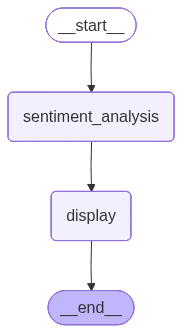

In [11]:
app

In [12]:
app.invoke({"review" : "This is good product"})

'Review : This is good product\n  Sentiment : \n\nPositive'

In [13]:
app.invoke({"review" : "This is bad product"})

'Review : This is bad product\n  Sentiment : \n\nNegative'

#### Coditional Edges :

In [ ]:
## Review  --> LLM (Sentiment)   --> if sentiment=="positive": write thank you note
##                                    else : write sorry note

In [ ]:
# Nodes :
Sentiment

Thank you note
Apology Note

In [14]:
def sentiment_analysis(state):
  review = state["review"]
  sentiment = model.invoke(f"""Give me sentiment of given review, only return positive or negative, review : {review}""")
  state["sentiment"] = sentiment
  return state


def thank_you_note(state):
  review = state["review"]
  thank_you = model.invoke(f"""write a short thank you note for customers review, review : {review}""")
  state["note"] = thank_you
  return state

def apology_note(state):
  review = state["review"]
  apology = model.invoke(f"""write a short apology note for customers review, review : {review}""")
  state["note"] = apology
  return state

In [16]:
def router(state):
  sentiment = state["sentiment"]

  if "positive" in sentiment.lower():
    return "+"
  else:
    return "-"

In [18]:
from langgraph.graph import StateGraph, START, END

In [20]:
graph = StateGraph(dict)

graph.add_node("sentiment_analysis", sentiment_analysis)
graph.add_node("thank_you_note", thank_you_note)
graph.add_node("apology_note", apology_note)

graph.add_edge(START, "sentiment_analysis")

graph.add_conditional_edges(
    "sentiment_analysis",
    router,
    {"+" : "thank_you_note", "-" : "apology_note"}
)

graph.add_edge("thank_you_note", END)
graph.add_edge("apology_note", END)


app = graph.compile()

In [22]:
# app

In [23]:
app.invoke({"review" : "Laptop quality is good also display is good"})

{'review': 'Laptop quality is good also display is good',
 'sentiment': '\n\nPositive',
 'note': '\n\nDear valued customer,\n\nWe would like to take a moment to express our sincere gratitude for your recent review of our laptop. Your kind words about the quality and display of our product mean a lot to us.\n\nWe strive to provide the best possible experience for our customers and your positive feedback reassures us that we are on the right track. We are constantly working to improve and your review serves as a motivation for us to continue delivering high-quality products.\n\nThank you once again for taking the time to share your thoughts. We truly appreciate your support and look forward to serving you in the future.\n\nBest regards,\n[Your Name] \n'}

In [24]:
app.invoke({"review" : "Laptop quality is bad also display is bad"})

{'review': 'Laptop quality is bad also display is bad',
 'sentiment': '\n\nNegative',
 'note': '\nDear Valued Customer,\n\nWe are extremely sorry to hear about your unsatisfactory experience with our laptop. We apologize for the poor quality and display that you have encountered.\n\nAt our company, we strive to provide our customers with high-quality products and we are disappointed that we have fallen short in meeting your expectations. We understand the importance of having a reliable laptop and we regret that we were unable to provide you with one.\n\nPlease be assured that we take your feedback seriously and we will be working towards improving our products and services. We appreciate your honest review and we will use it as a learning opportunity to better serve our customers in the future.\n\nOnce again, we apologize for any inconvenience this may have caused you and we hope to have the opportunity to make it up to you in the future.\n\nSincerely,\n[Your Name]'}

In [ ]:
1. State : Typed Dict with Annotation
2. Return value : Insted of returning full state, return partial state (only value changes by this node)

In [ ]:
# Typed Dict with Annotation

In [27]:
def add(a : int, b : int) -> int:
  return a + b

In [28]:
add("8", "1")

'81'

In [29]:
from typing import TypedDict

class State(TypedDict):
  review : str
  sentiment : str
  note : str

In [30]:
# Typed Dict with Annotation
from typing import TypedDict
from typing_extensions import Annotated

class State(TypedDict):
  review : Annotated[str, "This is user review"]
  sentiment : Annotated[str, "Sentiment of a review"]
  note : Annotated[str, "Apology or Thank you note based by sentiment"]

In [31]:
def sentiment_analysis(state):
  review = state["review"]
  sentiment = model.invoke(f"""Give me sentiment of given review, only return positive or negative, review : {review}""")
  # state["sentiment"] = sentiment
  return {"sentiment" : sentiment}


def thank_you_note(state):
  review = state["review"]
  thank_you = model.invoke(f"""write a short thank you note for customers review, review : {review}""")
  # state["note"] = thank_you
  return {"note" : thank_you}

def apology_note(state):
  review = state["review"]
  apology = model.invoke(f"""write a short apology note for customers review, review : {review}""")
  # state["note"] = apology
  return {"note" : apology}

In [32]:
graph = StateGraph(State)

graph.add_node("sentiment_analysis", sentiment_analysis)
graph.add_node("thank_you_note", thank_you_note)
graph.add_node("apology_note", apology_note)

graph.add_edge(START, "sentiment_analysis")

graph.add_conditional_edges(
    "sentiment_analysis",
    router,
    {"+" : "thank_you_note", "-" : "apology_note"}
)

graph.add_edge("thank_you_note", END)
graph.add_edge("apology_note", END)


app = graph.compile()

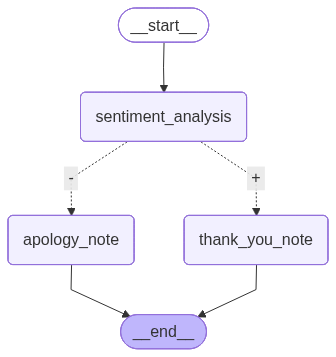

In [33]:
app

In [34]:
app.invoke({"review" : "Laptop quality is good also display is good"})

{'review': 'Laptop quality is good also display is good',
 'sentiment': '\n\nPositive',
 'note': '\n\nDear valued customer,\n\nThank you so much for taking the time to review our laptop. We are thrilled to hear that you are satisfied with the quality and display of our product. Your feedback is greatly appreciated and will help us continue to provide the best products and services to our customers.\n\nWe are committed to delivering high-quality and reliable laptops to enhance your overall experience. Your review not only encourages us but also helps other potential customers make an informed decision.\n\nThank you once again for choosing our laptop and for your kind words. We look forward to serving you again in the future.\n\nBest regards, \n[Your Name] '}

###Agentic RAG :

In [ ]:
# E-commerce